In [8]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [13]:
class BMI(TypedDict):
    weight_kg: float
    height_m: float
    bmi: float
    label: str
    

In [15]:
def calc_lbl(State: BMI) ->BMI:
    bmi= State['bmi']

    if bmi <18.5:
        State['label'] = "Underweight"
    elif 18.5<=bmi <25:
        State["label"] = "NOrmal"
    elif 25 <=bmi <30:
        State['label'] =  "Overweight" 
    else:
        State["label"] = 'obese' 

    return State        

In [16]:
def calc_bmi(state: BMI) ->BMI:
    weight = state['weight_kg']
    height = state["height_m"]
    bmi    = weight/(height**2)
    state['bmi'] = round(bmi, 2)

    return state



In [17]:
graph = StateGraph(BMI)

## added node 
graph.add_node('calc_bmi', calc_bmi)
graph.add_node('calc_lbl', calc_lbl)
graph.add_edge(START,'calc_bmi')
graph.add_edge('calc_bmi', 'calc_lbl')
graph.add_edge('calc_lbl',END)

work= graph.compile()



In [18]:
out =work.invoke({'weight_kg':56,'height_m':1.73})
print(out)


{'weight_kg': 56, 'height_m': 1.73, 'bmi': 18.71, 'label': 'NOrmal'}


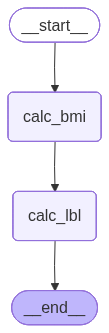

In [19]:
from IPython.display import Image
Image(work.get_graph().draw_mermaid_png())